In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

c:\Users\msi\anaconda3\envs\winekg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_json("../src/data/raw.json")

In [3]:
df["region"] = df.apply(
    lambda row: row["province"]
    if pd.isna(row["region_1"]) or row["province"] == row["region_1"]
    else f"{row['province']}, {row['region_1']}",
    axis=1
)

In [29]:
# Unique Columns
df.columns

Index(['points', 'title', 'description', 'taster_name',
       'taster_twitter_handle', 'price', 'designation', 'variety', 'region_1',
       'region_2', 'province', 'country', 'winery'],
      dtype='str')

In [31]:
# Number of NaNs for each column
df.info()

# Can see that price is missing for ~9000 wines, designation is missing for ~30000 wines, and ~20000 for region.
# For missing regions, we can use the province instead - E.g. Douro wines

<class 'pandas.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   points                 129971 non-null  int64  
 1   title                  129971 non-null  str    
 2   description            129971 non-null  str    
 3   taster_name            103727 non-null  str    
 4   taster_twitter_handle  98758 non-null   str    
 5   price                  120975 non-null  float64
 6   designation            92506 non-null   str    
 7   variety                129970 non-null  str    
 8   region_1               108724 non-null  str    
 9   region_2               50511 non-null   str    
 10  province               129908 non-null  str    
 11  country                129908 non-null  str    
 12  winery                 129971 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 12.9 MB


In [25]:
nan_region_counts = df[df.region_1.isna()]['province'].value_counts()[:10].to_dict()

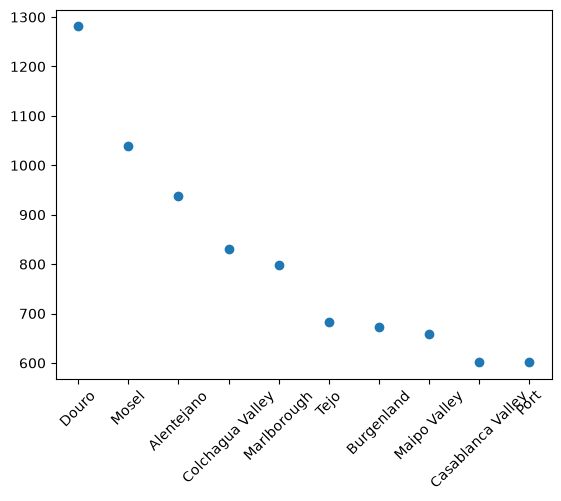

In [28]:
plt.xticks(rotation=45)
province = nan_region_counts.keys()
freq = nan_region_counts.values()
plt.scatter(x=province, y=freq)

In [35]:
df[df.designation.isna()]

,points,title,description,taster_name,taster_twitter_handle,price,designation,variety,region_1,region_2,province,country,winery
2,87,Rainstorm 2013 Pinot Gris (Willamette Valley),"Tart and snappy, the flavors of lime flesh and...",Paul Gregutt,@paulgwine,14.0,NaN,Pinot Gris,Willamette Valley,Willamette Valley,Oregon,US,Rainstorm
7,87,Trimbach 2012 Gewurztraminer (Alsace),This dry and restrained wine offers spice in p...,Roger Voss,@vossroger,24.0,NaN,Gewürztraminer,Alsace,NaN,Alsace,France,Trimbach
11,87,Leon Beyer 2012 Gewurztraminer (Alsace),"This is a dry wine, very spicy, with a tight, ...",Roger Voss,@vossroger,30.0,NaN,Gewürztraminer,Alsace,NaN,Alsace,France,Leon Beyer
12,87,Louis M. Martini 2012 Cabernet Sauvignon (Alex...,"Slightly reduced, this wine offers a chalky, t...",Virginie Boone,@vboone,34.0,NaN,Cabernet Sauvignon,Alexander Valley,Sonoma,California,US,Louis M. Martini
14,87,Mirassou 2012 Chardonnay (Central Coast),Building on 150 years and six generations of w...,Matt Kettmann,@mattkettmann,12.0,NaN,Chardonnay,Central Coast,Central Coast,California,US,Mirassou
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129952,90,Houdini 2011 Zinfandel (Chiles Valley),This Zinfandel from the eastern section of Nap...,Virginie Boone,@vboone,22.0,NaN,Zinfandel,Chiles Valley,Napa,California,US,Houdini
129955,90,Dog Point 2012 Chardonnay (Marlborough),"Like Dog Point's 2011 Chardonnay, this wine is...",Joe Czerwinski,@JoeCz,40.0,NaN,Chardonnay,NaN,NaN,Marlborough,New Zealand,Dog Point
129961,90,COS 2013 Frappato (Sicilia),"Intense aromas of wild cherry, baking spice, t...",Kerin O’Keefe,@kerinokeefe,30.0,NaN,Frappato,Sicilia,NaN,Sicily & Sardinia,Italy,COS
129967,90,Citation 2004 Pinot Noir (Oregon),Citation is given as much as a decade of bottl...,Paul Gregutt,@paulgwine,75.0,NaN,Pinot Noir,Oregon,Oregon Other,Oregon,US,Citation


In [ ]:
# Title, Description, designation, variety, region (region_1 + province), country, winery 

In [9]:
EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"
embedding_model = SentenceTransformer(EMBEDDING_MODEL, device='cpu')
embedding_model = embedding_model.to("cuda")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4574.59it/s]
